# AtlasFin RAG — Pipeline Exploration Notebook

This notebook walks through every stage of the pipeline in one place:

1. **Config** — load an experiment config and inspect all knobs
2. **Gold set** — explore FinanceBench questions and evidence
3. **Chunks** — inspect pre-built chunks from disk
4. **Embedding** — embed a query and inspect the vector (needs `VOYAGE_API_KEY`)
5. **Local retrieval** — dense + hybrid against `LocalBruteForceVectorStore` (no Vertex spend)
6. **Reranking** — cross-encoder before/after comparison
7. **Eval metrics** — recall@k, MRR, precision@5 against the gold set
8. **Experiment comparison** — diff two configs side-by-side
9. **Per-question deep-dive** — find misses and inspect them

---
### Prerequisites
```bash
uv sync --dev          # install deps including jupyter
export VOYAGE_API_KEY=your-voyage-key
export GEMINI_API_KEY=your-gemini-key   # only for contextual_prefix / query_transform
uv run jupyter lab
```
Cells that call external APIs are marked **[KEY REQUIRED]**.

In [44]:
# Cell 0 — run this first every session
# Adds repo root to sys.path and loads API keys from .env if present.
import sys, os
from pathlib import Path

REPO_ROOT = Path("__file__").resolve().parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Auto-load .env from repo root (never committed — see .env.example)
_env_path = REPO_ROOT / ".env"
if _env_path.exists():
    for _line in _env_path.read_text().splitlines():
        _line = _line.strip()
        if _line and not _line.startswith("#") and "=" in _line:
            _k, _, _v = _line.partition("=")
            os.environ.setdefault(_k.strip(), _v.strip())
    print(f"Loaded keys from {_env_path}")
else:
    print(f"No .env found at {_env_path} — create it from .env.example")
    print("  Or set keys manually: os.environ['VOYAGE_API_KEY'] = 'your-key'")

voyage_set = bool(os.environ.get("VOYAGE_API_KEY"))
gemini_set = bool(os.environ.get("GEMINI_API_KEY"))
print(f"VOYAGE_API_KEY set : {voyage_set}")
print(f"GEMINI_API_KEY set : {gemini_set}")
print(f"Repo root          : {REPO_ROOT}")
print(f"Python             : {sys.version}")

Loaded keys from /Users/sulabh/Documents/Projects/atlasfin-rag/.env
VOYAGE_API_KEY set : True
GEMINI_API_KEY set : True
Repo root          : /Users/sulabh/Documents/Projects/atlasfin-rag
Python             : 3.12.13 (main, May 10 2026, 19:20:41) [Clang 22.1.3 ]


## 1. Config — load an experiment and inspect all knobs

In [45]:
import dataclasses, json
from atlasfin.config.loader import load_experiment_config

CONFIG_PATH = REPO_ROOT / "atlasfin/experiments/configs/baseline_dense_3m.yaml"

spec = load_experiment_config(CONFIG_PATH)
cfg  = spec.config

print(f"Experiment name    : {cfg.name}")
print(f"Offline fingerprint: {cfg.offline_fingerprint()}")
print(f"Ingest run URI     : {spec.ingest_run_uri}")
print(f"Docs to index      : {spec.doc_names}")
print()
print("--- Full config (JSON) ---")
print(json.dumps(dataclasses.asdict(cfg), indent=2))

Experiment name    : baseline_dense_3m
Offline fingerprint: v1-736f7b21f69b0662
Ingest run URI     : gs://atlasfin-raw-dev/run=20260801t000036z/
Docs to index      : ['3M_2015_10K', '3M_2016_10K', '3M_2017_10K', '3M_2018_10K', '3M_2019_10K', '3M_2020_10K', '3M_2021_10K', '3M_2022_10K', '3M_2023Q2_10Q']

--- Full config (JSON) ---
{
  "name": "baseline_dense_3m",
  "parsing": {
    "backend": "docling",
    "ocr": "auto",
    "table_mode": "structured",
    "keep_images": false
  },
  "chunking": {
    "strategy": "structure_aware",
    "max_tokens": 512,
    "overlap_tokens": 64,
    "contextual_prefix": false,
    "contextual_model": null,
    "metadata_fields": [
      "section",
      "pages",
      "doc_type",
      "doc_period",
      "company"
    ]
  },
  "embedding": {
    "model_id": "voyage-4",
    "dimension": null,
    "normalize": true,
    "batch_size": 64
  },
  "retrieval": {
    "mode": "dense",
    "fusion": "rrf",
    "bm25_weight": 0.5,
    "top_k": 20,
    "filters

In [46]:
# Show the offline/online split — which knobs invalidate the cache
import pandas as pd

knobs = [
    ("parsing",   "backend",           cfg.parsing.backend,           "offline"),
    ("parsing",   "ocr",               cfg.parsing.ocr,               "offline"),
    ("parsing",   "table_mode",        cfg.parsing.table_mode,        "offline"),
    ("chunking",  "strategy",          cfg.chunking.strategy,         "offline"),
    ("chunking",  "max_tokens",        cfg.chunking.max_tokens,       "offline"),
    ("chunking",  "overlap_tokens",    cfg.chunking.overlap_tokens,   "offline"),
    ("chunking",  "contextual_prefix", cfg.chunking.contextual_prefix,"offline"),
    ("embedding", "model_id",          cfg.embedding.model_id,        "offline"),
    ("embedding", "dimension",         cfg.embedding.dimension,       "offline"),
    ("embedding", "normalize",         cfg.embedding.normalize,       "offline"),
    ("retrieval", "mode",              cfg.retrieval.mode,            "online"),
    ("retrieval", "fusion",            cfg.retrieval.fusion,          "online"),
    ("retrieval", "top_k",             cfg.retrieval.top_k,           "online"),
    ("retrieval", "query_transform",   cfg.retrieval.query_transform, "online"),
    ("retrieval", "parent_child",      cfg.retrieval.parent_child,    "online"),
    ("reranking", "enabled",           cfg.reranking.enabled,         "online"),
    ("reranking", "model_id",          cfg.reranking.model_id,        "online"),
    ("reranking", "depth",             cfg.reranking.depth,           "online"),
]
df = pd.DataFrame(knobs, columns=["stage", "knob", "value", "type"])
df.style.map(
    lambda v: "background-color: #ffe0b2" if v == "offline" else "background-color: #c8e6c9",
    subset=["type"]
)

,stage,knob,value,type
0,parsing,backend,docling,offline
1,parsing,ocr,auto,offline
2,parsing,table_mode,structured,offline
3,chunking,strategy,structure_aware,offline
4,chunking,max_tokens,512,offline
5,chunking,overlap_tokens,64,offline
6,chunking,contextual_prefix,False,offline
7,embedding,model_id,voyage-4,offline
8,embedding,dimension,None,offline
9,embedding,normalize,True,offline


## 2. Gold set — explore FinanceBench questions and evidence

In [47]:
from atlasfin.eval.gold import load_gold_set

GOLD_PATH = REPO_ROOT / "financebench_open_source.jsonl"

gold_all = load_gold_set(GOLD_PATH)
gold_3m  = load_gold_set(GOLD_PATH, doc_names=spec.doc_names)

print(f"Total FinanceBench questions : {len(gold_all)}")
print(f"Questions grounded in 3M docs: {len(gold_3m)}")
print()

from collections import Counter
companies = Counter(g.company for g in gold_all)
print("Top companies in gold set:")
for company, count in companies.most_common(10):
    print(f"  {company:<20} {count} questions")

Total FinanceBench questions : 150
Questions grounded in 3M docs: 8

Top companies in gold set:
  PepsiCo              11 questions
  Amcor                9 questions
  Johnson & Johnson    9 questions
  3M                   8 questions
  AMD                  8 questions
  Best Buy             8 questions
  Boeing               8 questions
  American Express     7 questions
  MGM Resorts          7 questions
  Pfizer               6 questions


In [48]:
# Inspect a single gold record in detail
sample = gold_3m[0]
print(f"ID            : {sample.financebench_id}")
print(f"Company       : {sample.company}")
print(f"Doc           : {sample.doc_name}")
print(f"Question      : {sample.question}")
print(f"Answer        : {sample.answer}")
print(f"Evidence pages: {[e.evidence_page_num for e in sample.evidence]}")
print()
print("Evidence text (first item, first 400 chars):")
print(sample.evidence[0].evidence_text[:400], "...")

ID            : financebench_id_03029
Company       : 3M
Doc           : 3M_2018_10K
Question      : What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a response to the question by relying on the details shown in the cash flow statement.
Answer        : $1577.00
Evidence pages: [60]

Evidence text (first item, first 400 chars):
Table of Contents 
3M Company and Subsidiaries
Consolidated Statement of Cash Flow s
Years ended December 31
 
(Millions)
 
2018
 
2017
 
2016
 
Cash Flows from Operating Activities
 
 
 
 
 
 
 
Net income including noncontrolling interest
 
$
5,363 
$
4,869 
$
5,058 
Adjustments to reconcile net income including noncontrolling interest to net cash
provided by operating activities
 
 
 
 
 
 
 
D ...


## 3. Build offline artifacts — parse → chunk → embed → BM25

This is the main offline step. It reads your already-parsed documents from GCS,
chunks them, embeds them with Voyage, and saves everything to a local cache keyed
by the offline fingerprint. It only rebuilds if the fingerprint changes.

**Set your GCP project below and run the cell.** It will take a few minutes the
first time (embedding 8 x 10-K filings). On subsequent runs it loads from cache
instantly.

> **[KEY REQUIRED]** `VOYAGE_API_KEY`

In [49]:
# Set your GCP project here — used to access the GCS bucket where parsed docs live.
GCP_PROJECT  = "project-7dfc6f6c-1703-48a3-83b"   # your active gcloud project
GCP_LOCATION = "us-central1"

import logging, os
from atlasfin.pipeline.cache import offline_dir
from atlasfin.index.chunk_store import ChunkStore

logging.basicConfig(level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s — %(message)s")

fp          = cfg.offline_fingerprint()
off_dir     = offline_dir(fp)
chunks_path = off_dir / "chunks.jsonl"

print(f"Offline fingerprint : {fp}")
print(f"Cache dir           : {off_dir}")
print(f"Already cached      : {chunks_path.exists()}")
print()

if not chunks_path.exists():
    print("Cache MISS — running parse → chunk → embed → BM25 ...")
    print("(downloading parsed docs from GCS, embedding with Voyage — takes a few minutes)")

from atlasfin.pipeline.offline import build_offline

index = build_offline(
    cfg,
    spec.doc_names,
    ingest_run_uri=spec.ingest_run_uri,
    gcp_project=None,          # None = skip Vertex index creation (local smoke only)
    gcp_location=GCP_LOCATION,
    parse_device="auto",
)

store  = ChunkStore.load(index.chunks_path)
chunks = store.all_chunks()
print(f"\nOffline build complete.")
print(f"  Chunks          : {index.n_chunks}")
print(f"  Cache dir       : {index.offline_dir}")

2026-08-08 15:04:54,566 INFO atlasfin.pipeline.offline — pipeline.offline: fp=v1-736f7b21f69b0662 cache exists but doc_names changed, rebuilding
2026-08-08 15:04:54,566 INFO atlasfin.pipeline.offline — pipeline.offline: fingerprint=v1-736f7b21f69b0662 MISS, building


Offline fingerprint : v1-736f7b21f69b0662
Cache dir           : .atlasfin_cache/offline/v1-736f7b21f69b0662
Already cached      : True



2026-08-08 15:04:57,189 INFO atlasfin_ingest.stage1 — stage1: read 8 lines, 8 unique docs, 8 after filter
2026-08-08 15:04:59,164 INFO atlasfin.pipeline.corpus — corpus: 3M_2023Q2_10Q not pre-parsed under gs://atlasfin-raw-dev/run=20260801t000036z/, parsing live


KeyError: "no SourceRecord for doc_name='3M_2023Q2_10Q' to resolve a raw path"

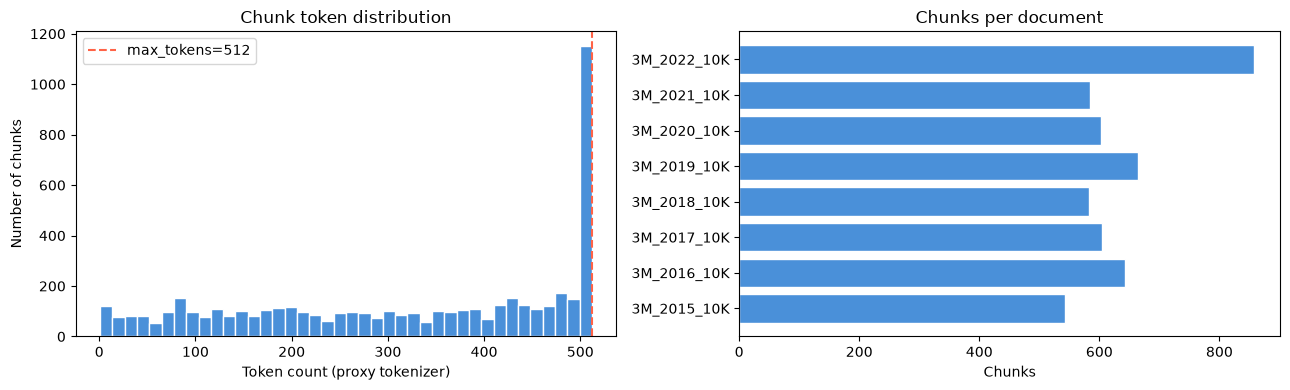

Total chunks : 5083
Avg tokens   : 320
Max tokens   : 512
Min tokens   : 1


In [27]:
# Inspect chunk distribution now that the cache is populated
import matplotlib.pyplot as plt
from collections import Counter

token_counts = [c.token_count for c in chunks]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(token_counts, bins=40, edgecolor="white", color="#4a90d9")
axes[0].axvline(cfg.chunking.max_tokens, color="tomato", linestyle="--",
                label=f"max_tokens={cfg.chunking.max_tokens}")
axes[0].set_xlabel("Token count (proxy tokenizer)")
axes[0].set_ylabel("Number of chunks")
axes[0].set_title("Chunk token distribution")
axes[0].legend()

per_doc = Counter(c.doc_name for c in chunks)
docs, counts = zip(*sorted(per_doc.items()))
axes[1].barh(docs, counts, color="#4a90d9", edgecolor="white")
axes[1].set_xlabel("Chunks")
axes[1].set_title("Chunks per document")

plt.tight_layout()
plt.show()

print(f"Total chunks : {len(chunks)}")
print(f"Avg tokens   : {sum(token_counts)/len(token_counts):.0f}")
print(f"Max tokens   : {max(token_counts)}")
print(f"Min tokens   : {min(token_counts)}")

In [28]:
# Print a few sample chunks
for i, c in enumerate(chunks[:3]):
    print(f"--- Chunk {i} ---")
    print(f"  chunk_id    : {c.chunk_id}")
    print(f"  doc_name    : {c.doc_name}")
    print(f"  section     : {c.section}")
    print(f"  pages       : {c.pages}")
    print(f"  token_count : {c.token_count}")
    print(f"  text[:200]  : {c.text[:200]}")
    print()

--- Chunk 0 ---
  chunk_id    : 3M_2015_10K#root#6c1ff09db3a7
  doc_name    : 3M_2015_10K
  section     : 
  pages       : [1]
  token_count : 1
  text[:200]  : low

--- Chunk 1 ---
  chunk_id    : 3M_2015_10K#securities-and-exchange-commission#4463578c79ae
  doc_name    : 3M_2015_10K
  section     : SECURITIES AND EXCHANGE COMMISSION
  pages       : [1]
  token_count : 8
  text[:200]  : Washington, D.C. 20549

--- Chunk 2 ---
  chunk_id    : 3M_2015_10K#form-10-k#85418927e3ae
  doc_name    : 3M_2015_10K
  section     : FORM 10-K
  pages       : [1]
  token_count : 35
  text[:200]  : ☒ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(d) OF THE
SECURITIES EXCHANGE ACT OF 1934
For the fiscal year ended December 31, 2015
Commission file number 1-3285



## 4. Embedding — embed a query and inspect the vector

> **[KEY REQUIRED]** `VOYAGE_API_KEY` must be set before running these cells.

In [29]:
from atlasfin.embedding import build as build_embedder

embedder = build_embedder(cfg.embedding)
print(f"Embedder model : {cfg.embedding.model_id}")
print(f"Normalize      : {cfg.embedding.normalize}")
print(f"Dimension      : {cfg.embedding.dimension or 'model native'}")

Embedder model : voyage-4
Normalize      : True
Dimension      : model native


In [30]:
import math

SAMPLE_QUERY = "What was 3M's capital expenditure in FY2018?"

query_vec = embedder.embed_query(SAMPLE_QUERY)
dim  = len(query_vec)
norm = math.sqrt(sum(x*x for x in query_vec))

print(f"Query        : {SAMPLE_QUERY}")
print(f"Vector dim   : {dim}")
print(f"L2 norm      : {norm:.6f}  (should be ~1.0 since normalize=True)")
print(f"First 8 dims : {[round(v, 4) for v in query_vec[:8]]}")

Query        : What was 3M's capital expenditure in FY2018?
Vector dim   : 1024
L2 norm      : 1.000000  (should be ~1.0 since normalize=True)
First 8 dims : [-0.0335, -0.0639, 0.0128, 0.0758, -0.0598, 0.0471, -0.0483, -0.0288]


In [31]:
# Verify query vs doc vectors differ (Voyage uses task-specific prefixes)
doc_vec = embedder.embed_docs([SAMPLE_QUERY])[0]
dot = sum(q*d for q, d in zip(query_vec, doc_vec))
print(f"Dot product (query_vec · doc_vec of SAME text): {dot:.4f}")
print("Should be < 1.0 — Voyage prepends different task prefixes for query vs document.")

Dot product (query_vec · doc_vec of SAME text): 0.7519
Should be < 1.0 — Voyage prepends different task prefixes for query vs document.


## 5. Local retrieval — dense + hybrid (no Vertex spend)

Uses `LocalBruteForceVectorStore` (in-memory exact search) instead of Vertex AI.
Loads from the artifacts built in Section 3.

In [32]:
# Wire up the local retriever from the index built in Section 3.
# Uses LocalBruteForceVectorStore (exact in-memory search, no Vertex spend).
import numpy as np
from atlasfin.index.local_vector_store import LocalBruteForceVectorStore
from atlasfin.index.bm25_store import BM25Store
from atlasfin.index.chunk_store import ChunkStore
from atlasfin.retrieval import build_local_smoke

chunk_store  = ChunkStore.load(index.chunks_path)
vector_store = LocalBruteForceVectorStore.load(index.embeddings_path, index.chunk_ids_path)
bm25_store   = BM25Store.load(index.bm25_path) if index.bm25_path.exists() else None

retriever = build_local_smoke(
    cfg.retrieval,
    embedding_cfg=cfg.embedding,
    chunking_cfg=cfg.chunking,
    chunk_store=chunk_store,
    vector_store=vector_store,
)
shape = vector_store._vectors.shape
print(f"Dense retriever ready — {len(chunk_store)} chunks, embedding matrix {shape}")
print(f"BM25 store loaded : {bm25_store is not None}")

Dense retriever ready — 5015 chunks, embedding matrix (5083, 1024)
BM25 store loaded : True


In [33]:
# Run a single query and print the top-k candidates
if retriever is not None:
    query = "What was 3M's capital expenditure in FY2018?"
    candidates = retriever.retrieve(query, k=cfg.retrieval.top_k)

    print(f"Query: {query}")
    print(f"Top {len(candidates)} candidates:\n")
    for rank, c in enumerate(candidates, 1):
        print(f"  [{rank:>2}] score={c.score:.4f}  pages={c.pages}  doc={c.chunk_id.split('#')[0]}")
        print(f"       {c.text[:120].strip()} ...")

Query: What was 3M's capital expenditure in FY2018?
Top 20 candidates:

  [ 1] score=0.7112  pages=[46, 47]  doc=3M_2018_10K
       Purchases of property, plant and equipment (PP&E), 2018 = $ (1,577). Purchases of property, plant and equipment (PP&E), ...
  [ 2] score=0.7077  pages=[39]  doc=3M_2018_10K
       Investments in property, plant and equipment enable growth across many diverse markets, helping to meet product demand a ...
  [ 3] score=0.6726  pages=[7, 8]  doc=3M_2018_10K
       3M's manufacturing operations are affected by national, state and local environmental laws around the world. 3M has made ...
  [ 4] score=0.6614  pages=[26]  doc=3M_2018_10K
       3M generated $6.4 billion of operating cash flow in 2018, an increase of $199 million when compared to 2017. This follow ...
  [ 5] score=0.6597  pages=[49]  doc=3M_2018_10K
       Major GAAP Cash Flow Categories, 2018 = . Major GAAP Cash Flow Categories, 2017 = . Major GAAP Cash Flow Categories, 201 ...
  [ 6] score=0.657

In [34]:
# Compare dense vs hybrid (RRF) side-by-side
import dataclasses

if retriever is not None and bm25_store is not None:
    hybrid_cfg = dataclasses.replace(cfg.retrieval, mode="hybrid", fusion="rrf")
    hybrid_retriever = build_local_smoke(
        hybrid_cfg,
        embedding_cfg=cfg.embedding,
        chunking_cfg=cfg.chunking,
        chunk_store=chunk_store,
        vector_store=vector_store,
        bm25_store=bm25_store,
    )

    dense_ids    = [c.chunk_id for c in candidates]
    hybrid_cands = hybrid_retriever.retrieve(query, k=cfg.retrieval.top_k)
    hybrid_ids   = [c.chunk_id for c in hybrid_cands]

    only_dense  = [cid for cid in dense_ids  if cid not in hybrid_ids]
    only_hybrid = [cid for cid in hybrid_ids if cid not in dense_ids]

    print(f"Dense  top-{cfg.retrieval.top_k}: {len(set(dense_ids))} unique chunks")
    print(f"Hybrid top-{cfg.retrieval.top_k}: {len(set(hybrid_ids))} unique chunks")
    print(f"In dense but not hybrid : {len(only_dense)}")
    print(f"In hybrid but not dense : {len(only_hybrid)}  ← BM25 surfaced these")
else:
    print("Skipped: retriever or BM25 store not available.")

Dense  top-20: 20 unique chunks
Hybrid top-20: 20 unique chunks
In dense but not hybrid : 10
In hybrid but not dense : 10  ← BM25 surfaced these


## 6. Reranking — cross-encoder before/after comparison

Runs locally via `sentence-transformers` — no API key required.
Green shift = moved up in ranking, red = moved down.

In [35]:
from atlasfin.config.schema import RerankingConfig
from atlasfin.reranking import build as build_reranker

rerank_cfg = RerankingConfig(
    enabled=True,
    model_id="cross-encoder/ms-marco-MiniLM-L-6-v2",
    depth=20,
    max_pair_tokens=512,
)
reranker = build_reranker(rerank_cfg)
print("Reranker loaded (sentence-transformers, runs locally — no API key needed)")

2026-08-08 14:54:09,595 INFO sentence_transformers.base.model — No device provided, using mps
2026-08-08 14:54:09,763 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:54:09,864 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 404 Not Found"
2026-08-08 14:54:09,868 INFO sentence_transformers.base.model — No modules.json found for cross-encoder/ms-marco-MiniLM-L-6-v2, initializing a new CrossEncoder model.
2026-08-08 14:54:09,960 INFO httpx — HTTP Request: GET https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L-6-v2 "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:54:10,084 INFO httpx — HTTP Request: GET https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L6-v2 "HTTP/1.1 200 OK"
2026-08-08 14:54:10,188 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/m

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

2026-08-08 14:54:10,920 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/processor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:54:11,026 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-08-08 14:54:11,125 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:54:11,222 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-08-08 14:54:11,322 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:54:11,422 INFO httpx — HTTP Request: HEAD https://huggingface.co/c

Reranker loaded (sentence-transformers, runs locally — no API key needed)


In [36]:
if retriever is not None:
    reranked = reranker.rerank(query, candidates, depth=rerank_cfg.depth)

    before_rank = {c.chunk_id: i + 1 for i, c in enumerate(candidates)}
    rows = []
    for after_rank, c in enumerate(reranked, 1):
        before = before_rank.get(c.chunk_id, "?")
        shift  = (before - after_rank) if isinstance(before, int) else 0
        rows.append({
            "after_rank" : after_rank,
            "before_rank": before,
            "shift"      : shift,
            "score"      : round(c.score, 4),
            "pages"      : c.pages,
            "text_preview": c.text[:80].replace("\n", " "),
        })

    df_rerank = pd.DataFrame(rows)

    def color_shift(val):
        if val > 0: return "color: green"
        if val < 0: return "color: red"
        return ""

    print(f"Query: {query}")
    display(df_rerank.style.map(color_shift, subset=["shift"]))
else:
    print("Skipped: retriever not available.")

Query: What was 3M's capital expenditure in FY2018?


,after_rank,before_rank,shift,score,pages,text_preview
0,1,2,1,2.289300,[39],"Investments in property, plant and equipment enable growth across many diverse m"
1,2,15,13,2.251800,[37],"Investments in property, plant and equipment enable growth across many diverse m"
2,3,13,10,2.103900,[37],"Investments in property, plant and equipment enable growth across many diverse m"
3,4,14,10,2.010300,[39],"Investments in property, plant and equipment enable growth across many diverse m"
4,5,11,6,1.585900,[43],The strength and stability of 3M's business model and strong free cash flow capa
5,6,3,-3,1.166300,"[7, 8]","3M's manufacturing operations are affected by national, state and local environm"
6,7,19,12,1.062000,[8],"3M's manufacturing operations are affected by national, state and local environm"
7,8,4,-4,0.631800,[26],"3M generated $6.4 billion of operating cash flow in 2018, an increase of $199 mi"
8,9,7,-2,-1.296600,[34],"Investments in property, plant and equipment enable growth across many diverse m"
9,10,8,-2,-1.296600,[30],"Investments in property, plant and equipment enable growth across many diverse m"


## 7. Eval metrics — score recall@k, MRR, latency

> **[KEY REQUIRED]** `VOYAGE_API_KEY` | Requires offline cache.

In [37]:
import time
from atlasfin.pipeline.answer import AnswerResult
from atlasfin.eval.score import score as eval_score

if retriever is None:
    print("Skipped: offline artifacts not found.")
else:
    print(f"Scoring {len(gold_3m)} questions ...")
    results = []
    for g in gold_3m:
        t0    = time.perf_counter()
        cands = retriever.retrieve(g.question, k=cfg.retrieval.top_k)
        ms    = (time.perf_counter() - t0) * 1000
        results.append(AnswerResult(question=g.question, candidates=cands,
                                    retrieve_ms=ms, rerank_ms=None))

    metrics = eval_score(results, gold_3m)
    print("\n--- Metrics (dense, no rerank) ---")
    print(f"  recall@5    : {metrics.recall_at[5]:.3f}")
    print(f"  recall@10   : {metrics.recall_at[10]:.3f}")
    print(f"  recall@20   : {metrics.recall_at[20]:.3f}")
    print(f"  MRR         : {metrics.mrr:.3f}")
    print(f"  retrieve p50: {metrics.retrieve_latency_p50:.1f} ms")
    print(f"  retrieve p95: {metrics.retrieve_latency_p95:.1f} ms")

Scoring 5 questions ...

--- Metrics (dense, no rerank) ---
  recall@5    : 0.000
  recall@10   : 0.200
  recall@20   : 0.400
  MRR         : 0.036
  retrieve p50: 118.5 ms
  retrieve p95: 120.9 ms


2026-08-08 14:54:26,644 INFO matplotlib.category — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-08 14:54:26,645 INFO matplotlib.category — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


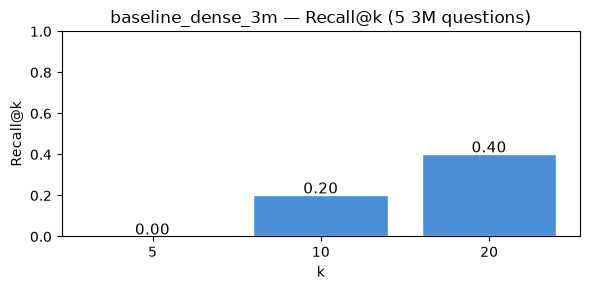

In [38]:
# Recall@k bar chart
if retriever is not None:
    import matplotlib.pyplot as plt

    ks      = sorted(metrics.recall_at.keys())
    recalls = [metrics.recall_at[k] for k in ks]

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar([str(k) for k in ks], recalls, color="#4a90d9", edgecolor="white")
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("k")
    ax.set_ylabel("Recall@k")
    ax.set_title(f"{cfg.name} — Recall@k ({len(gold_3m)} 3M questions)")
    for i, (k, r) in enumerate(zip(ks, recalls)):
        ax.text(i, r + 0.01, f"{r:.2f}", ha="center", fontsize=11)
    plt.tight_layout()
    plt.show()

## 8. Experiment comparison — diff two configs side-by-side

`baseline_dense_3m` vs `hybrid_rerank_3m`.
Both share the same offline fingerprint, so no rebuild is needed for B.

In [39]:
from atlasfin.config.loader import load_experiment_config

spec_a = load_experiment_config(REPO_ROOT / "atlasfin/experiments/configs/baseline_dense_3m.yaml")
spec_b = load_experiment_config(REPO_ROOT / "atlasfin/experiments/configs/hybrid_rerank_3m.yaml")

fp_a, fp_b = spec_a.config.offline_fingerprint(), spec_b.config.offline_fingerprint()
print(f"Config A: {spec_a.config.name}  fingerprint: {fp_a}")
print(f"Config B: {spec_b.config.name}  fingerprint: {fp_b}")
print()
if fp_a == fp_b:
    print("✓ Same fingerprint — shared cached artifacts, no rebuild needed for B")
else:
    print("✗ Different fingerprints — B would trigger a rebuild")

Config A: baseline_dense_3m  fingerprint: v1-736f7b21f69b0662
Config B: hybrid_rerank_3m  fingerprint: v1-736f7b21f69b0662

✓ Same fingerprint — shared cached artifacts, no rebuild needed for B


In [40]:
# Show exactly which knobs differ
import dataclasses

def _flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else k
        out.update(_flatten(v, key)) if isinstance(v, dict) else out.update({key: v})
    return out

fa, fb = _flatten(dataclasses.asdict(spec_a.config)), _flatten(dataclasses.asdict(spec_b.config))
diffs  = [(k, fa[k], fb[k]) for k in fa if fa[k] != fb.get(k)]

print(f"Knobs that differ ({len(diffs)} total):\n")
for k, va, vb in diffs:
    print(f"  {k:<35} {str(va):<20} → {vb}")

Knobs that differ (4 total):

  name                                baseline_dense_3m    → hybrid_rerank_3m
  retrieval.mode                      dense                → hybrid
  reranking.enabled                   False                → True
  reranking.model_id                  None                 → cross-encoder/ms-marco-MiniLM-L-6-v2


In [43]:
# Side-by-side metrics comparison (requires offline cache)
if retriever is not None and bm25_store is not None:
    hybrid_retriever_b = build_local_smoke(
        spec_b.config.retrieval,
        embedding_cfg=spec_b.config.embedding,
        chunking_cfg=spec_b.config.chunking,
        chunk_store=chunk_store,
        vector_store=vector_store,
        bm25_store=bm25_store,
    )
    reranker_b = build_reranker(spec_b.config.reranking)

    results_b = []
    for g in gold_3m:
        t0    = time.perf_counter()
        cands = hybrid_retriever_b.retrieve(g.question, k=spec_b.config.retrieval.top_k)
        r_ms  = (time.perf_counter() - t0) * 1000
        t1    = time.perf_counter()
        cands = reranker_b.rerank(g.question, cands, depth=spec_b.config.reranking.depth)
        rr_ms = (time.perf_counter() - t1) * 1000
        results_b.append(AnswerResult(question=g.question, candidates=cands,
                                      retrieve_ms=r_ms, rerank_ms=rr_ms))

    metrics_b = eval_score(results_b, gold_3m)

    comparison = pd.DataFrame([
        {"metric": "recall@5",     "A (dense)": f"{metrics.recall_at[5]:.3f}",   "B (hybrid+rerank)": f"{metrics_b.recall_at[5]:.3f}"},
        {"metric": "recall@10",    "A (dense)": f"{metrics.recall_at[10]:.3f}",  "B (hybrid+rerank)": f"{metrics_b.recall_at[10]:.3f}"},
        {"metric": "recall@20",    "A (dense)": f"{metrics.recall_at[20]:.3f}",  "B (hybrid+rerank)": f"{metrics_b.recall_at[20]:.3f}"},
        {"metric": "MRR",          "A (dense)": f"{metrics.mrr:.3f}",            "B (hybrid+rerank)": f"{metrics_b.mrr:.3f}"},
        {"metric": "precision@5",  "A (dense)": "n/a (no rerank)",               "B (hybrid+rerank)": f"{metrics_b.precision_at_5:.3f}"},
        {"metric": "p50 retrieve", "A (dense)": f"{metrics.retrieve_latency_p50:.1f}ms", "B (hybrid+rerank)": f"{metrics_b.retrieve_latency_p50:.1f}ms"},
        {"metric": "p50 rerank",   "A (dense)": "n/a",                           "B (hybrid+rerank)": f"{metrics_b.rerank_latency_p50:.1f}ms"},
    ]).set_index("metric")
    display(comparison)
else:
    print("Skipped: offline artifacts not found.")

2026-08-08 14:57:50,124 INFO sentence_transformers.base.model — No device provided, using mps
2026-08-08 14:57:50,288 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:57:50,387 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 404 Not Found"
2026-08-08 14:57:50,391 INFO sentence_transformers.base.model — No modules.json found for cross-encoder/ms-marco-MiniLM-L-6-v2, initializing a new CrossEncoder model.
2026-08-08 14:57:50,489 INFO httpx — HTTP Request: GET https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L-6-v2 "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:57:50,594 INFO httpx — HTTP Request: GET https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L6-v2 "HTTP/1.1 200 OK"
2026-08-08 14:57:50,693 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/m

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

2026-08-08 14:57:51,437 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/processor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:57:51,536 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-08-08 14:57:51,636 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:57:51,731 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
2026-08-08 14:57:51,837 INFO httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-08 14:57:51,939 INFO httpx — HTTP Request: HEAD https://huggingface.co/c

,A (dense),B (hybrid+rerank)
metric,,
recall@5,0.000,0.000
recall@10,0.200,0.000
recall@20,0.400,0.400
MRR,0.036,0.021
precision@5,n/a (no rerank),0.000
p50 retrieve,118.5ms,115.9ms
p50 rerank,n/a,101.6ms


## 9. Per-question deep-dive — find misses and inspect them

Which questions are recall misses at k=5 but hits at k=20?
What does the ranked list look like for those questions?

In [42]:
from atlasfin.eval.metrics import _is_hit

if retriever is not None:
    miss_at_5_hit_at_20 = [
        (g, res)
        for g, res in zip(gold_3m, results)
        if not any(_is_hit(c, g.evidence) for c in res.candidates[:5])
        and     any(_is_hit(c, g.evidence) for c in res.candidates[:20])
    ]

    print(f"Miss@5 but Hit@20: {len(miss_at_5_hit_at_20)} questions\n")
    for g, res in miss_at_5_hit_at_20[:3]:
        gold_pages = [e.evidence_page_num for e in g.evidence]
        print(f"Q: {g.question[:100]}")
        print(f"   Gold pages: {gold_pages}")
        for rank, c in enumerate(res.candidates[:20], 1):
            hit    = _is_hit(c, g.evidence)
            marker = "  ← GOLD HIT" if hit else ""
            print(f"   [{rank:>2}] pages={c.pages} score={c.score:.4f}{marker}")
        print()
else:
    print("Skipped: retriever not available.")

Miss@5 but Hit@20: 2 questions

Q: Assume that you are a public equities analyst. Answer the following question by primarily using info
   Gold pages: [58]
   [ 1] pages=[41] score=0.7465
   [ 2] pages=[77] score=0.6568
   [ 3] pages=[46, 47] score=0.6552
   [ 4] pages=[2] score=0.6535
   [ 5] pages=[41] score=0.6517
   [ 6] pages=[48] score=0.6439
   [ 7] pages=[39] score=0.6358
   [ 8] pages=[58] score=0.6292  ← GOLD HIT
   [ 9] pages=[59] score=0.6287
   [10] pages=[39] score=0.6286
   [11] pages=[124] score=0.6274
   [12] pages=[60] score=0.6251
   [13] pages=[36] score=0.6234
   [14] pages=[137] score=0.6218
   [15] pages=[57] score=0.6205
   [16] pages=[127] score=0.6184
   [17] pages=[42] score=0.6140
   [18] pages=[81] score=0.6131
   [19] pages=[124] score=0.6108
   [20] pages=[46] score=0.6094

Q: What drove operating margin change as of FY2022 for 3M? If operating margin is not a useful metric f
   Gold pages: [27]
   [ 1] pages=[32] score=0.7421
   [ 2] pages=[21] score=0.7